# **Import Library**

In [ ]:
import os
import cv2
import numpy as np
import kagglehub, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# **Konfigurasi Dataset**

In [ ]:
#Download dataset dari Kaggle
path = kagglehub.dataset_download("vencerlanz09/agricultural-pests-image-dataset")

dataset_path = os.path.join(path, "agricultural-pests-image-dataset") \
    if os.path.exists(os.path.join(path, "agricultural-pests-image-dataset")) else path

#Daftar kelas
classes = [
    'ants', 'bees', 'beetle', 'catterpillar', 'earthworms', 'earwig',
    'grasshopper', 'moth', 'slug', 'snail', 'wasp', 'weevil'
]

print(f"Dataset path: {dataset_path}")
print(f"Total kelas: {len(classes)}")
print(f"Contoh isi: {os.listdir(dataset_path)[:5]}")


Using Colab cache for faster access to the 'agricultural-pests-image-dataset' dataset.
📁 Dataset path: /kaggle/input/agricultural-pests-image-dataset
🔢 Total kelas: 12
📂 Contoh isi: ['beetle', 'grasshopper', 'earthworms', 'ants', 'earwig']


# **Prepocessing**

In [ ]:
def full_preprocessing(img_path, size=(256,256)):
    #Baca gambar
    img = cv2.imread(img_path)
    if img is None:
        return None

    #Resize & konversi ke RGB
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    #Konversi ke grayscale (untuk citra biner)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #Thresholding (citra biner)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    #Filtering (Gaussian blur)
    blurred = cv2.GaussianBlur(img, (3,3), 0)

    #Image Enhancement (Equalisasi histogram)
    img_yuv = cv2.cvtColor(blurred, cv2.COLOR_RGB2YUV)
    img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
    enhanced = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

    #Normalisasi (0-1)
    normalized = enhanced / 255.0

    return normalized.astype('float32')

# **Dataset Dengan Prepocessing**

In [ ]:
X, y = [], []

for label_idx, class_name in enumerate(classes):
    class_folder = os.path.join(dataset_path, class_name)
    if not os.path.exists(class_folder):
        print(f"Folder tidak ditemukan: {class_folder}")
        continue

    images = os.listdir(class_folder)[:max_images_per_class]
    for img_name in images:
        img_path = os.path.join(class_folder, img_name)
        processed = full_preprocessing(img_path, size=img_size)
        if processed is not None:
            X.append(processed)
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print(f"✅ Total gambar yang berhasil diproses: {len(X)}")
print("Shape data X:", X.shape)
print("Shape data y:", y.shape)

✅ Total gambar yang berhasil diproses: 600
Shape data X: (600, 256, 256, 3)
Shape data y: (600,)


# **Split Data dan encoding**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# One-hot encoding label
y_train = to_categorical(y_train, num_classes=len(classes))
y_val = to_categorical(y_val, num_classes=len(classes))

print("Data training:", X_train.shape)
print("Data validation:", X_val.shape)


Data training: (480, 256, 256, 3)
Data validation: (120, 256, 256, 3)


# **Bangun model CNN**

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Summary Model**

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    29,491,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,588,684 (112.87 MB)

 Trainable params: 29,588,236 (112.87 MB)

 Non-trainable params: 448 (1.75 KB)

# **Callback untuk early stopping**

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.h5", save_best_only=True)
]


# **Training Model**

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)


Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1286 - loss: 7.7951

30/30 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.1282 - loss: 7.7894 - val_accuracy: 0.1000 - val_loss: 3.4183
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 128s 4s/step - accuracy: 0.3622 - loss: 2.5711 - val_accuracy: 0.1000 - val_loss: 5.3820
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step - accuracy: 0.5506 - loss: 1.3687 - val_accuracy: 0.0917 - val_loss: 5.3952
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.6646 - loss: 0.9654 - val_accuracy: 0.1167 - val_loss: 5.1648
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.7669 - loss: 0.7052 - val_accuracy: 0.0917 - val_loss: 5.9873
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.7629 - loss: 0.6823 - val_accuracy: 0.0917 - val_loss: 7.6597


# **Visualisasi hasil**

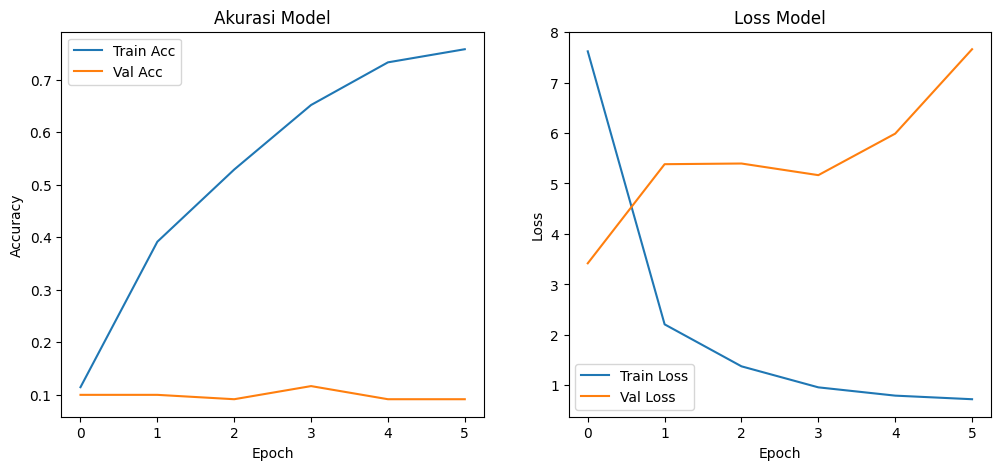

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


# **Simpan Model**

In [ ]:
model.save("pest_classifier_cnn.h5")
print("✅ Model berhasil disimpan sebagai pest_classifier_cnn.h5")

✅ Model berhasil disimpan sebagai pest_classifier_cnn.h5
